In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Batch gradient descent
Batch : Each steps of gradient descent uses all the training examples

In [48]:
def compute_gradient(x, y, w, b):

    m = len(x) # total length of training dataset
    dj_dw = 0 # the gradient of cost j w.r.t. the parameter w
    dj_db = 0 # the gradient of cost j w.r.t. the parameter b
    
    for i in range(m):
        # predicted value
        f_wb_xi = w * x[i] + b # y_hat = f_wb_xi
        
        # calculate derivative term
        dj_dw_i = (f_wb_xi - y[i]) * x[i]
        dj_db_i = f_wb_xi - y[i]
        
        # addition derivative term
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    
    # divide by training examples
    dj_dw = (1 / m) * dj_dw
    dj_db = (1 / m) * dj_db
    
    # result
    return (dj_dw, dj_db)
    
# w = w - a * dj_dw
# b = b - a * dj_db
# a -> Learning rate 

# Scratch Linear Regression model

epoch : How many times entire training dataset reuse(reuse -> repeadtely learning algorithm process)

Intuitively, in one epoch the entire training dataset passes through the learning algorithm(model).

[Training dataset] -> [model] 


In [80]:
class LinearRegression:
    def __init__(self):
        # Initializing the parameters w and b
        self.w = 0.0 # weight
        self.b = 0.0 # bias
    
    def fit(self, X, y, lr = 0.01, epochs=1000):
        # X -> features, y -> actual data, lr -> learning rate
        m = len(X) # no. of training examples
        
        for epoch in range(epochs):             
            # prediction
            y_hat = self.w * X + self.b
            
            # calculate error 
            error = (y_hat - y)
            
            # normalize gradients
            dw = (1 / m) * np.sum(error * X)
            db = (1 / m) * np.sum(error)
                
            # parameters update
            self.w -= lr * dw
            self.b -= lr * db
        
        return self.w, self.b
    
    def predict(self, X):
        X = np.asarray(X)
        # X = (X - np.mean(X)) / np.std(X)
        
        y_hat = self.w * X + self.b
        return y_hat


In [50]:
# Load data from dataset
house_df = pd.read_csv('melb_data.csv.zip')
# house_df.head()
# house_df.isnull().sum()
house_df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='str')

In [81]:
# feature names
feature_names = ['Lattitude', 'Longtitude', 'Rooms']

# DataFrame single feature-> X
X  = house_df['Rooms']

# target values
y = house_df['Price']

model = LinearRegression()
# fit dataset
model.fit(X, y)

# predication
y_hat = model.predict(X)

y_hat = np.array(y_hat)
# for i in range(len(y_hat)):
print(y_hat)

# cost function(J(w,b))
m = len(X)
# J = (1 / (2 * m)) * np.sum((y_hat - y)**2)
J = (0.5 * m) * np.sum((y_hat - y)**2)
print(J)



[ 764586.06281131  764586.06281131 1096373.0759995  ... 1096373.0759995
 1428160.08918769 1428160.08918769]
2.838974263916711e+19


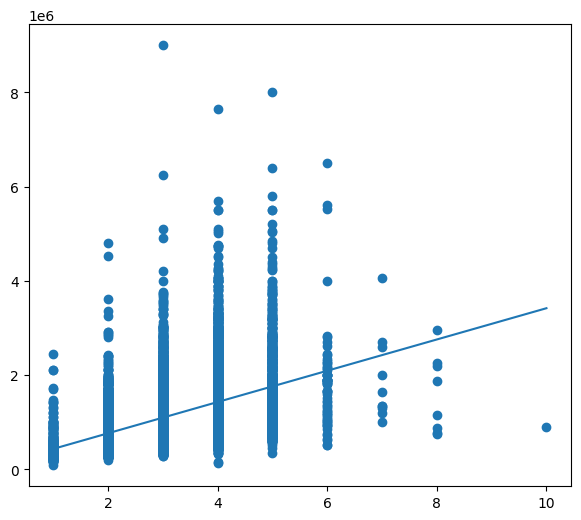

In [70]:
i = np.argsort(X)
X_sort = X[i]
y_sort = y[i]
y_hat_sort = y_hat[i]

fig, ax = plt.subplots(figsize=(7,6))
# Actual data 
ax.scatter(X, y)

# predicated data
ax.plot(X_sort, y_hat_sort)

plt.show()

In [84]:
from sklearn.linear_model import LinearRegression

# feature names
feature_names = ['Lattitude', 'Longtitude', 'Rooms']

# DataFrame -> X
X = pd.DataFrame(house_df['Rooms'])

# actual data
y = house_df['Price']

model = LinearRegression()
model.fit(X, y)
y_hat_b = model.predict(X)

print(f"Built-in model result\n {y_hat_b}")
print(f"\nOwn model result\n {y_hat}")


Built-in model result
 [ 764077.75788488  764077.75788488 1096281.70253265 ... 1096281.70253265
 1428485.64718043 1428485.64718043]

Own model result
 [ 764586.06281131  764586.06281131 1096373.0759995  ... 1096373.0759995
 1428160.08918769 1428160.08918769]
